# Практическая работа 1. Метод k ближайших соседей

Задание 1 из `Задание_1.docx`. Блокнот выполнен полностью; таблицы и рисунки сохранены в `results/`.

In [1]:
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from ml_utils import (scores, cv_splits, evaluate_cv, savefig, table, save_json,
                      environment, boundaries, noise_experiment, RESULTS)

from sklearn.neighbors import KNeighborsClassifier, VALID_METRICS

## Исходные данные и порядок оценки


Исходные `make_moons`, число объектов, `noise=0.2`, `random_state=42` и исходное
разбиение 70/30 сохранены. Координаты синтетические, поэтому оси названы x₁ и x₂.
Подбор параметров выполняется только внутри train: 5 стратифицированных фолдов ×
3 повтора, seed=2026. Все настройки сравниваются на одних и тех же разбиениях.
Основной критерий — средняя accuracy CV; затем F1, затем меньший разброс accuracy.
Тест используется после выбора параметров. Стандартное отклонение по фолдам
показывает разброс, но не является доверительным интервалом.

Дополнительный опыт с шумом: 20 парных разбиений только train, 25% на валидацию;
в обучающей части меняются метки 0/5/10/20% объектов. Валидационные метки остаются
исходными. Эти результаты описывают устойчивость, но не участвуют в подборе.

train/test: (700, 2) (300, 2)
Классы train/test: [344 356] [156 144]


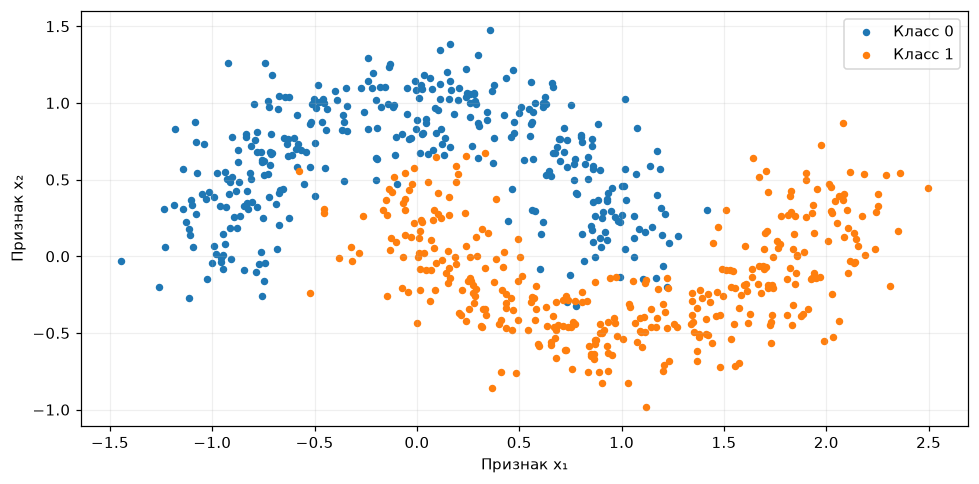

In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
splits = cv_splits(X_train, y_train)
print('train/test:', X_train.shape, X_test.shape)
print('Классы train/test:', np.bincount(y_train), np.bincount(y_test))
for label in [0, 1]:
    plt.scatter(*X_train[y_train == label].T, s=15, label=f'Класс {label}')
plt.xlabel('Признак x₁'); plt.ylabel('Признак x₂'); plt.legend()
savefig('knn_data')

## Реализация вручную
Расстояния вычисляются по всем признакам. Реализованы euclidean, manhattan,
chebyshev и minkowski (p ≥ 1), равномерные и обратные расстоянию веса.
При нулевом расстоянии голосуют только совпавшие точки. При равенстве голосов
выбирается меньшая метка класса; на границе k равные расстояния сохраняют порядок train.

In [3]:
def k_neibours(X_train, y_train, X_test, k_neib=1, weights='uniform', metric='euclidean', p=2):
    X_train, X_test = np.asarray(X_train, dtype=float), np.asarray(X_test, dtype=float)
    y_train = np.asarray(y_train)
    if X_train.ndim != 2 or X_test.ndim != 2 or X_train.shape[1] != X_test.shape[1]:
        raise ValueError('X_train и X_test должны иметь одинаковое число признаков')
    if y_train.ndim != 1 or len(y_train) != len(X_train):
        raise ValueError('Неверная длина y_train')
    if not isinstance(k_neib, (int, np.integer)) or not 1 <= k_neib <= len(X_train):
        raise ValueError('k должно быть целым от 1 до размера train')
    if not np.isfinite(X_train).all() or not np.isfinite(X_test).all():
        raise ValueError('Нужны конечные числовые признаки')
    if weights not in ['uniform', 'distance']:
        raise ValueError('Неизвестная схема весов')
    if metric not in ['euclidean', 'manhattan', 'chebyshev', 'minkowski'] or p < 1:
        raise ValueError('Неизвестная метрика или p < 1')
    classes = np.unique(y_train)
    predictions = []
    for point in X_test:
        difference = np.abs(X_train - point)
        if metric == 'euclidean':
            distances = np.sqrt(np.sum(difference ** 2, axis=1))
        elif metric == 'manhattan':
            distances = np.sum(difference, axis=1)
        elif metric == 'chebyshev':
            distances = np.max(difference, axis=1)
        else:
            distances = np.sum(difference ** p, axis=1) ** (1 / p)
        nearest = np.argsort(distances, kind='stable')[:k_neib]
        distances = distances[nearest]
        if weights == 'uniform':
            votes = np.ones(k_neib)
        elif np.any(distances == 0):
            votes = (distances == 0).astype(float)
        else:
            votes = 1 / distances
        totals = [votes[y_train[nearest] == label].sum() for label in classes]
        predictions.append(classes[np.argmax(totals)])
    return np.array(predictions, dtype=y_train.dtype)

# Сравнение с независимой библиотечной реализацией на 72 сочетаниях.
checks = 0
for metric, p in [('euclidean', 2), ('manhattan', 2), ('chebyshev', 2),
                  ('minkowski', 1.5), ('minkowski', 3), ('minkowski', 4)]:
    for k, weights in product([1, 3, 5, 15, 31, 51], ['uniform', 'distance']):
        reference = KNeighborsClassifier(n_neighbors=k, weights=weights,
                                         metric=metric, p=p, algorithm='brute').fit(X_train, y_train)
        actual = k_neibours(X_train, y_train, X_test, k, weights, metric, p)
        np.testing.assert_array_equal(actual, reference.predict(X_test))
        checks += 1
# Совпавшие точки, ничья голосов, произвольные классы, >2 признаков.
np.testing.assert_array_equal(k_neibours([[0], [0], [1]], [1, 1, 0], [[0]], 3, 'distance'), [1])
np.testing.assert_array_equal(k_neibours([[0], [2]], [2, 5], [[1]], 2), [2])
np.testing.assert_array_equal(k_neibours([[0, 0, 0], [0, 0, 2]], [2, 5], [[0, 0, 1.9]]), [5])
for invalid in [0, len(X_train) + 1]:
    try:
        k_neibours(X_train, y_train, X_test, invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Ожидалась ошибка при недопустимом k')
print(f'Проверено {checks} сочетания с sklearn и 5 граничных случаев')
manual_prediction = k_neibours(X_train, y_train, X_test, 5)
manual_scores = scores(y_test, manual_prediction)
print('Ручной k-NN, k=5:', manual_scores)

Проверено 72 сочетания с sklearn и 5 граничных случаев
Ручной k-NN, k=5: {'accuracy': 0.9733333333333334, 'f1': 0.971830985915493}


## Перебор k, weights и metric
Перебираются 13 значений k от 1 до 501, обе схемы весов и 15 спецификаций
расстояния. k=501 нужен, чтобы увидеть чрезмерное сглаживание (в CV обучение
содержит 560 точек). Отдельные срезы сравнивают один параметр при фиксированных остальных.

Махаланобис и стандартизованное евклидово расстояние получают ковариацию/дисперсии
только из обучающей части каждого фолда. Это исключает утечку валидационных данных.
Исходные координаты не масштабируются: так сохранена геометрия `make_moons`.

In [4]:
K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51, 101, 201, 501]
METRICS = {
    'euclidean': ('euclidean', {}),
    'manhattan': ('manhattan', {}),
    'chebyshev': ('chebyshev', {}),
    'minkowski_p1': ('minkowski', {'p': 1}),
    'minkowski_p1.5': ('minkowski', {'p': 1.5}),
    'minkowski_p2': ('minkowski', {'p': 2}),
    'minkowski_p3': ('minkowski', {'p': 3}),
    'minkowski_p4': ('minkowski', {'p': 4}),
    'sqeuclidean': ('sqeuclidean', {}),
    'seuclidean': ('seuclidean', {}),
    'mahalanobis': ('mahalanobis', {}),
    'cosine': ('cosine', {}),
    'correlation': ('correlation', {}),
    'canberra': ('canberra', {}),
    'braycurtis': ('braycurtis', {}),
}
def make_knn(X_fit, k=5, weights='uniform', metric_name='euclidean'):
    metric, extra = METRICS[metric_name]
    extra = dict(extra)
    if metric == 'seuclidean':
        extra['metric_params'] = {'V': X_fit.var(axis=0, ddof=1)}
    elif metric == 'mahalanobis':
        extra['metric_params'] = {'VI': np.linalg.inv(np.cov(X_fit.T))}
    return KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric,
                                algorithm='brute', n_jobs=1, **extra)

rows = []
for metric_name, weights, k in product(METRICS, ['uniform', 'distance'], K_VALUES):
    result = evaluate_cv(lambda fit: make_knn(fit, k, weights, metric_name),
                         X_train, y_train, splits)
    rows.append({'k': k, 'weights': weights, 'metric': metric_name, **result})
results = table(pd.DataFrame(rows), 'knn_grid')
ranked = results.sort_values(['cv_accuracy_mean', 'cv_f1_mean', 'cv_accuracy_std'],
                             ascending=[False, False, True], kind='stable')
winner = ranked.iloc[0]
best_config = {'k': int(winner.k), 'weights': str(winner.weights), 'metric_name': str(winner.metric)}
print('Всего конфигураций:', len(results))
display(ranked.head(10).round(5))
print('Выбрано по CV:', best_config)

Всего конфигураций: 390


,k,weights,metric,train_accuracy_mean,train_f1_mean,cv_accuracy_mean,cv_f1_mean,train_accuracy_std,train_f1_std,cv_accuracy_std,cv_f1_std
256,51,distance,seuclidean,1.00000,1.00000,0.97143,0.97213,0.00000,0.00000,0.01403,0.01344
46,21,distance,manhattan,1.00000,1.00000,0.97143,0.97208,0.00000,0.00000,0.01454,0.01400
98,21,distance,minkowski_p1,1.00000,1.00000,0.97143,0.97208,0.00000,0.00000,0.01454,0.01400
124,21,distance,minkowski_p1.5,1.00000,1.00000,0.97095,0.97160,0.00000,0.00000,0.01466,0.01414
238,9,uniform,seuclidean,0.97464,0.97519,0.97095,0.97160,0.00345,0.00335,0.01674,0.01610
237,7,uniform,seuclidean,0.97476,0.97529,0.97095,0.97165,0.00330,0.00318,0.01389,0.01329
47,31,distance,manhattan,1.00000,1.00000,0.97048,0.97121,0.00000,0.00000,0.01661,0.01589
99,31,distance,minkowski_p1,1.00000,1.00000,0.97048,0.97121,0.00000,0.00000,0.01661,0.01589
44,11,distance,manhattan,1.00000,1.00000,0.97048,0.97116,0.00000,0.00000,0.01475,0.01416
96,11,distance,minkowski_p1,1.00000,1.00000,0.97048,0.97116,0.00000,0.00000,0.01475,0.01416


Выбрано по CV: {'k': 51, 'weights': 'distance', 'metric_name': 'seuclidean'}


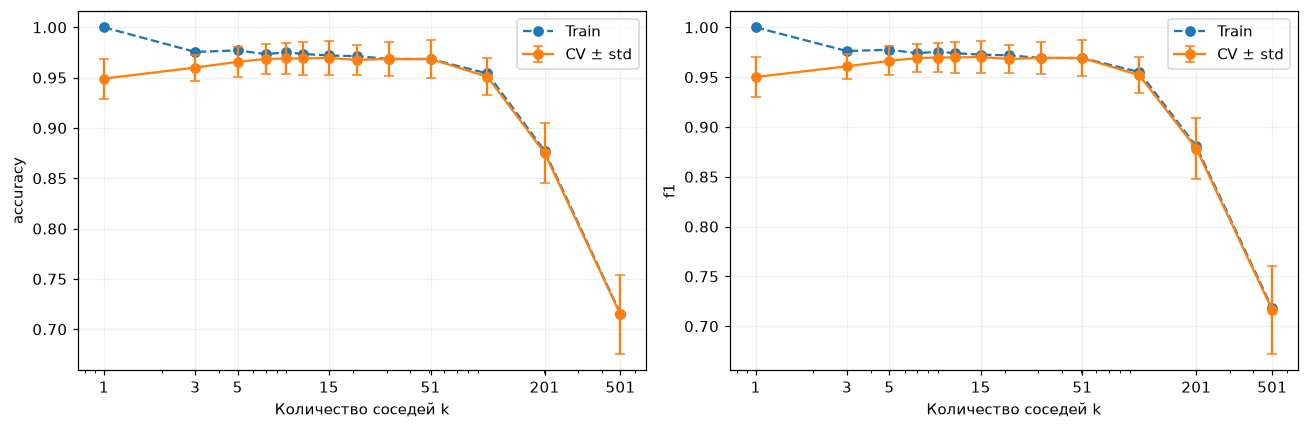

,k,train_accuracy_mean,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
0,1,1.0000,0.9490,0.0198,0.9501
1,3,0.9756,0.9600,0.0129,0.9609
2,5,0.9770,0.9657,0.0148,0.9664
3,7,0.9735,0.9686,0.0145,0.9692
4,9,0.9751,0.9690,0.0150,0.9696
5,11,0.9736,0.9690,0.0166,0.9698
6,15,0.9720,0.9695,0.0167,0.9702
7,21,0.9713,0.9676,0.0150,0.9683
8,31,0.9686,0.9686,0.0166,0.9693
9,51,0.9685,0.9686,0.0185,0.9692


,k,weights,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
2,5,uniform,0.9657,0.0148,0.9664
6,15,uniform,0.9695,0.0167,0.9702
9,51,uniform,0.9686,0.0185,0.9692
15,5,distance,0.9638,0.0154,0.9645
19,15,distance,0.9695,0.0170,0.9702
22,51,distance,0.9695,0.0158,0.9702


,metric,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
6,euclidean,0.9695,0.0167,0.9702
32,manhattan,0.9695,0.0167,0.9701
58,chebyshev,0.9686,0.0177,0.9692
84,minkowski_p1,0.9695,0.0167,0.9701
110,minkowski_p1.5,0.9686,0.0166,0.9692
136,minkowski_p2,0.9695,0.0167,0.9702
162,minkowski_p3,0.9686,0.0179,0.9692
188,minkowski_p4,0.9686,0.0179,0.9692
214,sqeuclidean,0.9695,0.0167,0.9702
240,seuclidean,0.9690,0.0154,0.9697


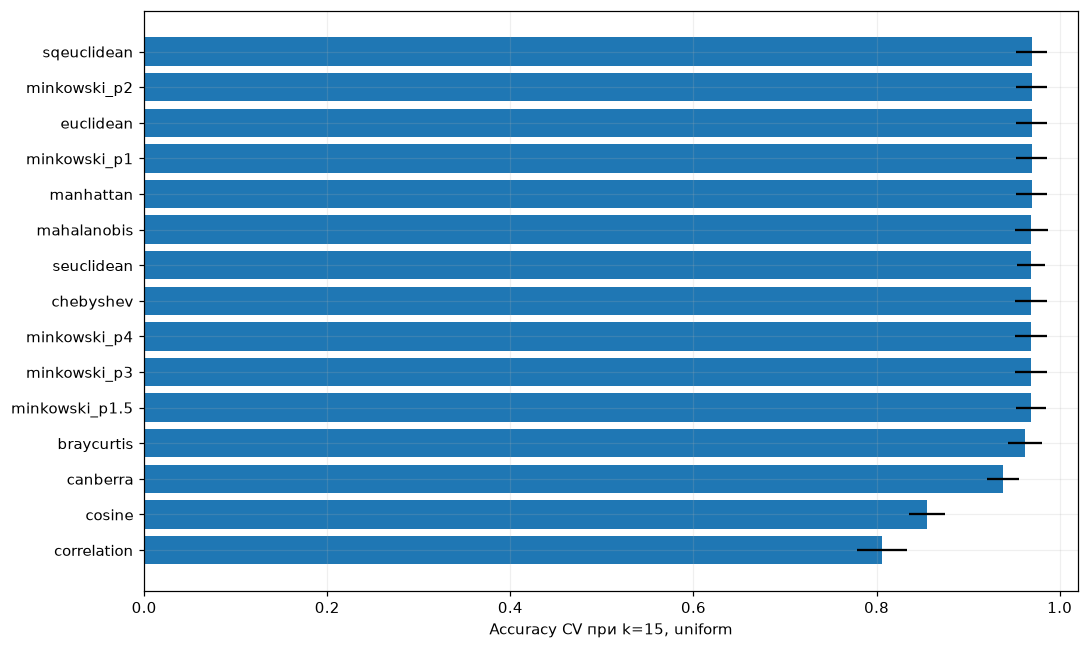

In [5]:
k_curve = table(results[(results.metric == 'euclidean') & (results.weights == 'uniform')], 'knn_k')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, measure in zip(axes, ['accuracy', 'f1']):
    ax.plot(k_curve.k, k_curve[f'train_{measure}_mean'], 'o--', label='Train')
    ax.errorbar(k_curve.k, k_curve[f'cv_{measure}_mean'], yerr=k_curve[f'cv_{measure}_std'],
                marker='o', capsize=3, label='CV ± std')
    ax.set(xlabel='Количество соседей k', ylabel=measure, xscale='log')
    ax.set_xticks([1, 3, 5, 15, 51, 201, 501], labels=[1, 3, 5, 15, 51, 201, 501])
    ax.legend()
savefig('knn_k')
display(k_curve[['k', 'train_accuracy_mean', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))

weights_table = table(results[(results.metric == 'euclidean') & (results.k.isin([5, 15, 51]))], 'knn_weights')
display(weights_table[['k', 'weights', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))
metric_table = table(results[(results.k == 15) & (results.weights == 'uniform')], 'knn_metrics')
display(metric_table[['metric', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_mean']].round(4))
plt.figure(figsize=(10, 6))
metric_order = metric_table.sort_values('cv_accuracy_mean')
plt.barh(metric_order.metric, metric_order.cv_accuracy_mean, xerr=metric_order.cv_accuracy_std)
plt.xlabel('Accuracy CV при k=15, uniform'); plt.xlim(0, 1.02)
savefig('knn_metrics')

### Область применимости расстояний
`minkowski(p=1)` совпадает с Manhattan, `minkowski(p=2)` — с Euclidean.
`cityblock/l1` и `l2` — псевдонимы. Квадрат евклидова расстояния сохраняет порядок
соседей, но при `distance` изменяет веса. Cosine и correlation игнорируют часть
геометрии; в двух измерениях correlation особенно вырождено. Canberra и
Bray–Curtis проверены как дополнительные меры различия; Bray–Curtis на знаковых
координатах не следует интерпретировать как обычную геометрическую метрику.

Бинарные меры (jaccard, dice, hamming, matching, rogerstanimoto, russellrao,
sokalmichener, sokalsneath, yule, kulsinski) не сохраняют смысл вещественных
координат; Hamming для почти всех разных непрерывных пар равен 1. Haversine
предназначен для широты/долготы. Jensen–Shannon требует неотрицательных
распределений вероятностей. `precomputed` — формат входа, callable — произвольная
функция, а не конечный список метрик. `nan_euclidean` без пропусков эквивалентна
euclidean. Поэтому фраза «всевозможные варианты» покрыта перечисленными числовыми
мерами и явным объяснением исключений, а не бессмысленным преобразованием данных.

Метрики, принимаемые brute в установленной sklearn: ['braycurtis', 'canberra', 'chebyshev', 'cityblock', 'correlation', 'cosine', 'dice', 'euclidean', 'hamming', 'haversine', 'jaccard', 'l1', 'l2', 'mahalanobis', 'manhattan', 'minkowski', 'nan_euclidean', 'precomputed', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalsneath', 'sqeuclidean', 'yule']


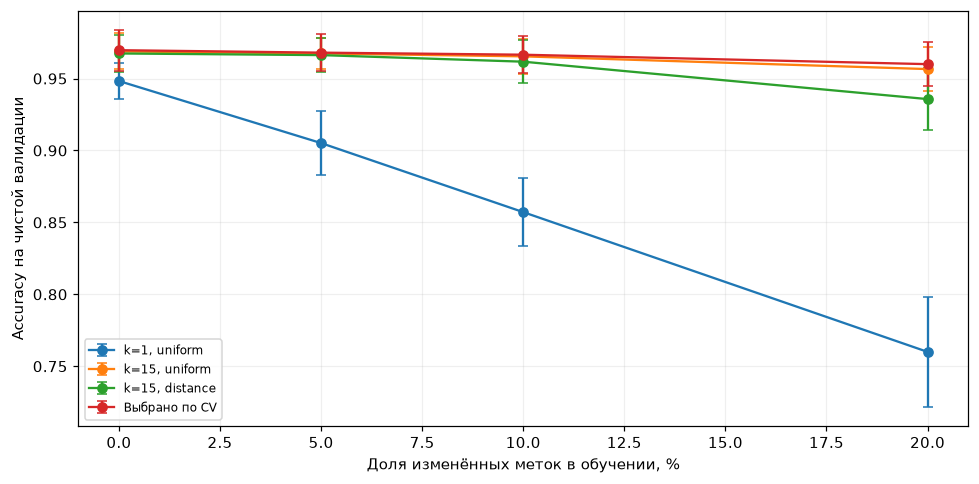

,model,noise,accuracy_mean,accuracy_std,f1_mean,f1_std,disagreement_mean
0,"k=1, uniform",0.00,0.9483,0.0125,0.9491,0.0123,0.0000
1,"k=1, uniform",0.05,0.9051,0.0221,0.9059,0.0224,0.0523
2,"k=1, uniform",0.10,0.8571,0.0237,0.8585,0.0241,0.1049
3,"k=1, uniform",0.20,0.7600,0.0382,0.7583,0.0447,0.2089
4,"k=15, uniform",0.00,0.9689,0.0125,0.9694,0.0123,0.0000
5,"k=15, uniform",0.05,0.9674,0.0110,0.9680,0.0107,0.0026
6,"k=15, uniform",0.10,0.9654,0.0122,0.9660,0.0120,0.0057
7,"k=15, uniform",0.20,0.9566,0.0153,0.9571,0.0156,0.0186
8,"k=15, distance",0.00,0.9674,0.0127,0.9680,0.0124,0.0000
9,"k=15, distance",0.05,0.9663,0.0120,0.9669,0.0119,0.0069


In [6]:
print('Метрики, принимаемые brute в установленной sklearn:', sorted(VALID_METRICS['brute']))
noise = noise_experiment({
    'k=1, uniform': lambda fit, seed: make_knn(fit, 1),
    'k=15, uniform': lambda fit, seed: make_knn(fit, 15, 'uniform'),
    'k=15, distance': lambda fit, seed: make_knn(fit, 15, 'distance'),
    'Выбрано по CV': lambda fit, seed: make_knn(fit, **best_config),
}, X_train, y_train, 'knn_noise')
display(noise.round(4))

## Итоговая оценка на test

Параметры зафиксированы по CV. Здесь test используется для итоговых метрик и рисунков.

,model,accuracy,f1
0,"Ручной k=5, uniform, euclidean",0.973333,0.971831
1,"sklearn k=5, uniform, euclidean",0.973333,0.971831
2,Выбрано по CV,0.976667,0.975610


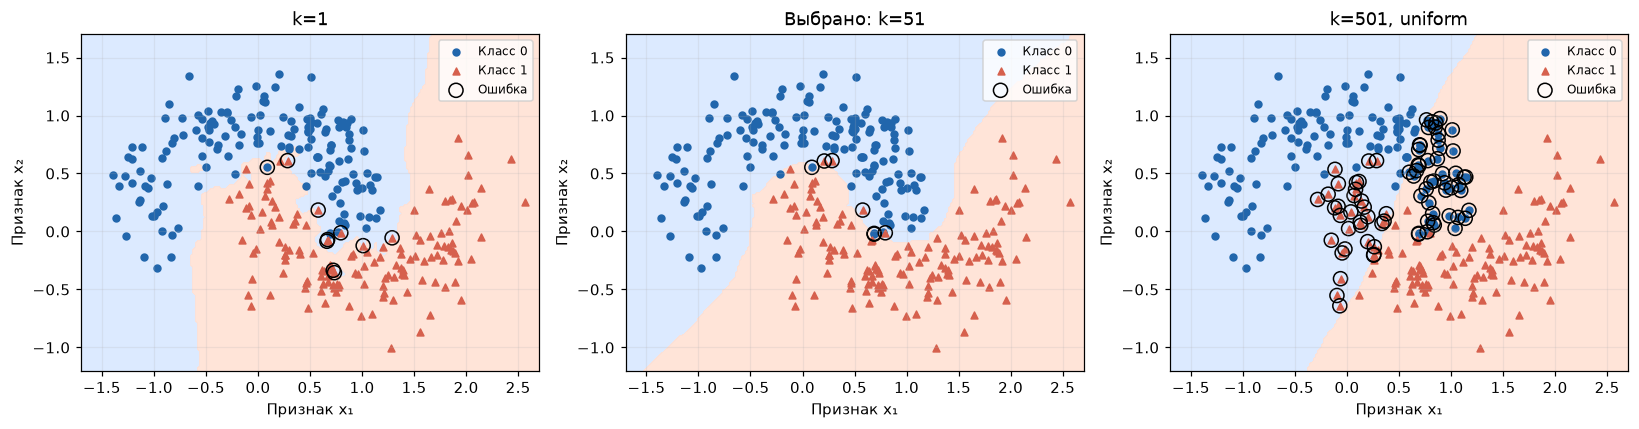

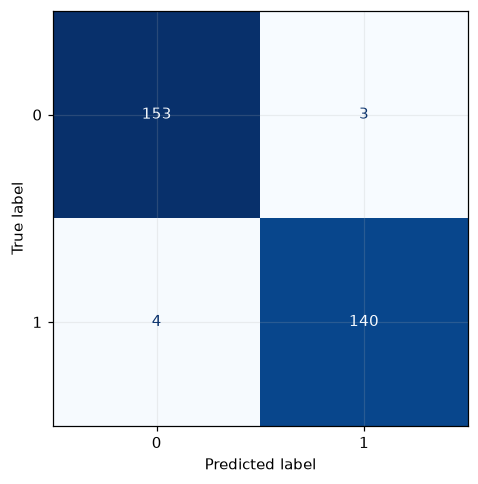

In [7]:
best_model = make_knn(X_train, **best_config).fit(X_train, y_train)
baseline = make_knn(X_train).fit(X_train, y_train)
best_test = scores(y_test, best_model.predict(X_test))
final = table(pd.DataFrame([
    {'model': 'Ручной k=5, uniform, euclidean', **manual_scores},
    {'model': 'sklearn k=5, uniform, euclidean', **scores(y_test, baseline.predict(X_test))},
    {'model': 'Выбрано по CV', **best_test},
]), 'knn_test')
display(final)
boundaries({'k=1': make_knn(X_train, 1).fit(X_train, y_train),
            f"Выбрано: k={best_config['k']}": best_model,
            'k=501, uniform': make_knn(X_train, 501).fit(X_train, y_train)}, X_test, y_test, 'knn_boundaries')
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues', colorbar=False)
savefig('knn_confusion')
save_json({'environment': environment(), 'best_params': best_config,
           'best_cv': {k: float(winner[k]) for k in winner.index if k.startswith('cv_')},
           'test': best_test, 'confusion': confusion_matrix(y_test, best_model.predict(X_test)).tolist(),
           'manual_sklearn_checks': checks, 'configurations': len(results),
           'train_size': len(y_train), 'test_size': len(y_test)}, 'knn_summary')

## Ответы и вывод
Малое k даёт локальную, неровную границу и повышенную чувствительность к изменённым
меткам; чрезмерно большое k сглаживает даже изгибы полумесяцев. Это проверяется
по кривой качества и рисунку границ. Uniform усредняет голоса, distance усиливает
ближайшие точки; сравнение устойчивости дано в отдельном опыте с шумом.

Оптимум в проверенной сетке напечатан выше и перенесён в `Отчёт_практическая_работа_1.md`.
Небольшие различия близких конфигураций не доказывают статистически значимого
превосходства; результат относится к данным и протоколу этой работы.

Источники: [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html),
[определения расстояний SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html).